<a href="https://colab.research.google.com/github/dinuvdm/Power-BI/blob/main/DataVizOnSoilDataNisar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import numpy as np
#filepath = "/content/NISAR_L3_PR_SME2_001_008_D_070_4000_QPNA_A_20190829T180759_20190829T180809_P01101_M_P_J_001.h5"
filepath = "https://github.com/ModelEarth/nisar/raw/refs/heads/main/colab/NISAR-Data-Compressed.rar"
rar_path = "/content/data.rar" # Where to save locally then uncompress .rar to .h5

# Data Source:
# Lvl 3 Soil Moisture from https://nisar.jpl.nasa.gov/data/sample-data/
# The downloaded .rar contains a .h5 file which is around 7mb.

# Download the .rar file
response = requests.get(filepath)
with open(rar_path, 'wb') as f:
    f.write(response.content)

## Get data info
By model.earth contributor Akshay Sakpal

In [ ]:
!apt-get install unrar -y
!pip install rarfile
import rarfile
import io
import h5py

# Open and extract the HDF5 file into memory
with rarfile.RarFile(rar_path) as rf:
    print("RAR contents:", rf.namelist())
    h5_filename = [f for f in rf.namelist() if f.endswith('.h5')][0]
    with rf.open(h5_filename) as h5_stream:
        h5_buffer = io.BytesIO(h5_stream.read())

# Open the HDF5 file directly from the in-memory buffer
with h5py.File(h5_buffer, 'r') as h5_file:
    print("HDF5 top-level keys:", list(h5_file.keys()))
    # Access datasets as needed, e.g., data = h5_file['your_dataset'][...]

    # Function to print the structure of the file
    def print_structure(name, obj):
        if isinstance(obj, h5py.Group):
            print(f"Group: {name}")
        elif isinstance(obj, h5py.Dataset):
            print(f"Dataset: {name}, Shape: {obj.shape}, Dtype: {obj.dtype}")

    # Print the structure
    print("File structure:")
    h5_file.visititems(print_structure)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
RAR contents: ['NISAR_L3_PR_SME2_001_008_D_070_4000_QPNA_A_20190829T180759_20190829T180809_P01101_M_P_J_001.h5']
HDF5 top-level keys: ['Algorithm', 'EASE_column_index', 'EASE_row_index', 'IncidenceAngle_aggregated', 'IncidenceAngle_aggregated_std', 'Landcover', 'NES0_hh', 'NES0_hv', 'NES0_vv', 'Numberoflooks_hh', 'Numberoflooks_hv', 'Numberoflooks_vv', 'Sigma0_hh_aggregated', 'Sigma0_hv_aggregated', 'Sigma0_vv_aggregated', 'Surface_Qflag', 'Waterbody_fraction', 'identification', 'latitude', 'longitude']
File structure:
Group: Algorithm
Group: Algorithm/DSG
Dataset: Algorithm/DSG/Algorithm_Param_Beta, Shape: (405, 450), Dtype: float32
Dataset: Algorithm/DSG/Algorithm_Param_Gamma, Shape: (405, 450), Dtype: float32
Dataset: Algorithm/DSG/Retrieval_Qflag, Shape: (405, 450), 

In [ ]:
import h5py
import pandas as pd
import numpy as np

# Open the HDF5 file
with h5py.File(h5_buffer, 'r') as h5_file:
    # Create a dictionary to store data
    data_dict = {}

    # Function to read datasets
    def read_datasets(name, obj):
        if isinstance(obj, h5py.Dataset):  # Only process datasets
            try:
                data = obj[()]

                # Decode string data if necessary
                if data.dtype.kind == 'S':
                    data = np.array([item.decode('utf-8') for item in data.flatten()]).reshape(data.shape)

                # Store the dataset
                data_dict[name] = data
                print(f"Read dataset '{name}', Shape: {data.shape}")
            except Exception as e:
                print(f"Error reading dataset '{name}': {e}")

    # Visit all items in the file and read datasets
    h5_file.visititems(read_datasets)

# Get latitude and longitude
latitude = data_dict['latitude']  # Shape: (405,)
longitude = data_dict['longitude']  # Shape: (450,)

# Create a meshgrid for latitude and longitude
lon_grid, lat_grid = np.meshgrid(longitude, latitude)

# Flatten the meshgrid
flat_lat = lat_grid.flatten()
flat_lon = lon_grid.flatten()

# Create a dictionary for flattened gridded data
flat_data_dict = {
    'latitude': flat_lat,
    'longitude': flat_lon
}

# Flatten all gridded datasets (shape (405, 450))
for key, data in data_dict.items():
    if data.shape == (405, 450):
        flat_data_dict[key] = data.flatten()

# Handle EASE indices
ease_row_index = data_dict['EASE_row_index']  # Shape: (405,)
ease_column_index = data_dict['EASE_column_index']  # Shape: (450,)

col_grid, row_grid = np.meshgrid(ease_column_index, ease_row_index)
flat_row = row_grid.flatten()
flat_col = col_grid.flatten()

flat_data_dict['EASE_row_index'] = flat_row
flat_data_dict['EASE_column_index'] = flat_col

# Create the DataFrame for gridded data
df = pd.DataFrame(flat_data_dict)

Read dataset 'Algorithm/DSG/Algorithm_Param_Beta', Shape: (405, 450)
Read dataset 'Algorithm/DSG/Algorithm_Param_Gamma', Shape: (405, 450)
Read dataset 'Algorithm/DSG/Retrieval_Qflag', Shape: (405, 450)
Read dataset 'Algorithm/DSG/Soil_moisture', Shape: (405, 450)
Read dataset 'Algorithm/DSG/Soil_moisture_uncertainty', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Croptype', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Dielectric_constant', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Retrieval_Qflag', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Roughness', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Soil_moisture', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Soil_moisture_uncertainty', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Vegetation_water_content_HV', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Vegetation_water_content_NDVI', Shape: (405, 450)
Read dataset 'Algorithm/PMI/Vegetation_water_content_estimate', Shape: (405, 450)
Read dataset 'Algorithm/TSR/Alpha1_paramet

In [ ]:
df.head(10)

,latitude,longitude,Algorithm/DSG/Algorithm_Param_Beta,Algorithm/DSG/Algorithm_Param_Gamma,Algorithm/DSG/Retrieval_Qflag,Algorithm/DSG/Soil_moisture,Algorithm/DSG/Soil_moisture_uncertainty,Algorithm/PMI/Croptype,Algorithm/PMI/Dielectric_constant,Algorithm/PMI/Retrieval_Qflag,...,Numberoflooks_hh,Numberoflooks_hv,Numberoflooks_vv,Sigma0_hh_aggregated,Sigma0_hv_aggregated,Sigma0_vv_aggregated,Surface_Qflag,Waterbody_fraction,EASE_row_index,EASE_column_index
0,36.287647,-90.745850,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43020
1,36.287647,-90.743774,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43021
2,36.287647,-90.741699,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43022
3,36.287647,-90.739624,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43023
4,36.287647,-90.737549,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43024
5,36.287647,-90.735474,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43025
6,36.287647,-90.733406,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43026
7,36.287647,-90.731331,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43027
8,36.287647,-90.729256,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43028
9,36.287647,-90.727180,-9999.0,-9999.0,-9999,-9999.0,-9999.0,3,-9999.0,7,...,-9999,-9999,-9999,-9999.0,-9999.0,-9999.0,-9999,0.0,14895,43029


In [ ]:
df.shape

(182250, 39)

In [ ]:
total_missing = (df == -9999).sum().sum()
print(f"Total number of -9999 values in the DataFrame: {total_missing}")

# Method 2: Count -9999 values for each column
missing_per_column = (df == -9999).sum()
print("\nNumber of -9999 values per column:")
print(missing_per_column)

# Method 3: If you want to check specific columns (e.g., soil moisture-related columns)
columns_to_check = ['Algorithm/DSG/Soil_moisture', 'Algorithm/DSG/Soil_moisture_uncertainty',
                    'Sigma0_hh_aggregated', 'Sigma0_hv_aggregated', 'Sigma0_vv_aggregated']
missing_in_specific_columns = (df[columns_to_check] == -9999).sum()
print("\nNumber of -9999 values in specific columns:")
print(missing_in_specific_columns)

Total number of -9999 values in the DataFrame: 2929438

Number of -9999 values per column:
latitude                                                0
longitude                                               0
Algorithm/DSG/Algorithm_Param_Beta                 101250
Algorithm/DSG/Algorithm_Param_Gamma                101250
Algorithm/DSG/Retrieval_Qflag                      110115
Algorithm/DSG/Soil_moisture                        110159
Algorithm/DSG/Soil_moisture_uncertainty            110159
Algorithm/PMI/Croptype                                  0
Algorithm/PMI/Dielectric_constant                  111057
Algorithm/PMI/Retrieval_Qflag                           0
Algorithm/PMI/Roughness                            111057
Algorithm/PMI/Soil_moisture                        111057
Algorithm/PMI/Soil_moisture_uncertainty            111057
Algorithm/PMI/Vegetation_water_content_HV          182250
Algorithm/PMI/Vegetation_water_content_NDVI             0
Algorithm/PMI/Vegetation_water_content_

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182250 entries, 0 to 182249
Data columns (total 39 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   latitude                                         182250 non-null  float32
 1   longitude                                        182250 non-null  float32
 2   Algorithm/DSG/Algorithm_Param_Beta               182250 non-null  float32
 3   Algorithm/DSG/Algorithm_Param_Gamma              182250 non-null  float32
 4   Algorithm/DSG/Retrieval_Qflag                    182250 non-null  int16  
 5   Algorithm/DSG/Soil_moisture                      182250 non-null  float32
 6   Algorithm/DSG/Soil_moisture_uncertainty          182250 non-null  float32
 7   Algorithm/PMI/Croptype                           182250 non-null  int8   
 8   Algorithm/PMI/Dielectric_constant                182250 non-null  float32
 9   Algorithm/PMI/R

In [ ]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 44.8 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


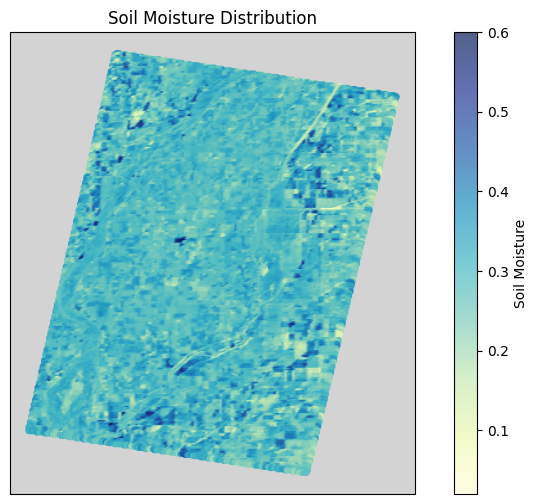

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
df.replace(-9999, pd.NA, inplace=True)
# Filter non-null soil moisture values
df_valid = df.dropna(subset=['Algorithm/DSG/Soil_moisture'])

# Create a map using cartopy
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Scatter plot of soil moisture
scatter = ax.scatter(df_valid['longitude'], df_valid['latitude'],
                     c=df_valid['Algorithm/DSG/Soil_moisture'], cmap='YlGnBu',
                     s=10, alpha=0.7, transform=ccrs.PlateCarree())

# Add colorbar
plt.colorbar(scatter, label='Soil Moisture')
plt.title('Soil Moisture Distribution')
plt.show()

In [ ]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72091 entries, 7834 to 166383
Data columns (total 39 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   latitude                                         72091 non-null  float32
 1   longitude                                        72091 non-null  float32
 2   Algorithm/DSG/Algorithm_Param_Beta               72091 non-null  object 
 3   Algorithm/DSG/Algorithm_Param_Gamma              72091 non-null  object 
 4   Algorithm/DSG/Retrieval_Qflag                    72091 non-null  object 
 5   Algorithm/DSG/Soil_moisture                      72091 non-null  object 
 6   Algorithm/DSG/Soil_moisture_uncertainty          72091 non-null  object 
 7   Algorithm/PMI/Croptype                           72091 non-null  int8   
 8   Algorithm/PMI/Dielectric_constant                71152 non-null  object 
 9   Algorithm/PMI/Retrieval_Qflag

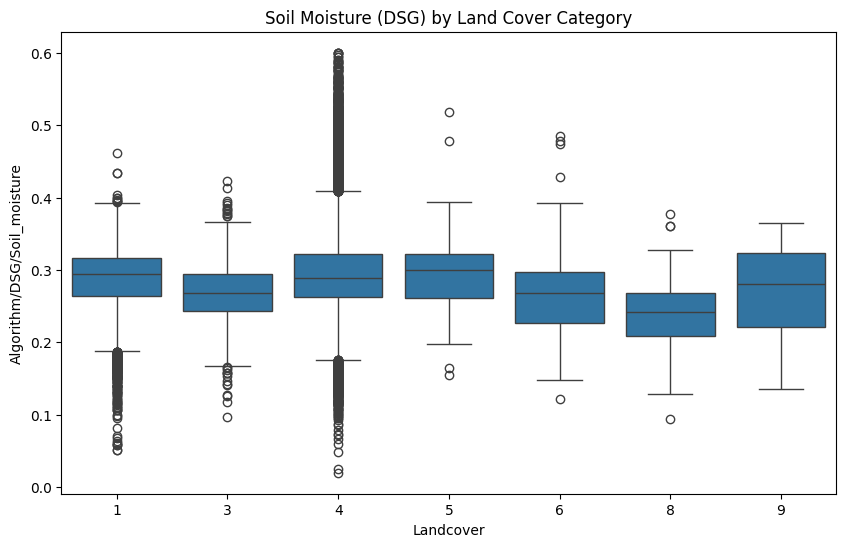

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert soil moisture to numeric
df['Algorithm/DSG/Soil_moisture'] = pd.to_numeric(df['Algorithm/DSG/Soil_moisture'], errors='coerce')

# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Landcover', y='Algorithm/DSG/Soil_moisture', data=df)
plt.title('Soil Moisture (DSG) by Land Cover Category')
plt.show()

In [ ]:
#df_valid.to_csv('df_valid.csv', index=False)

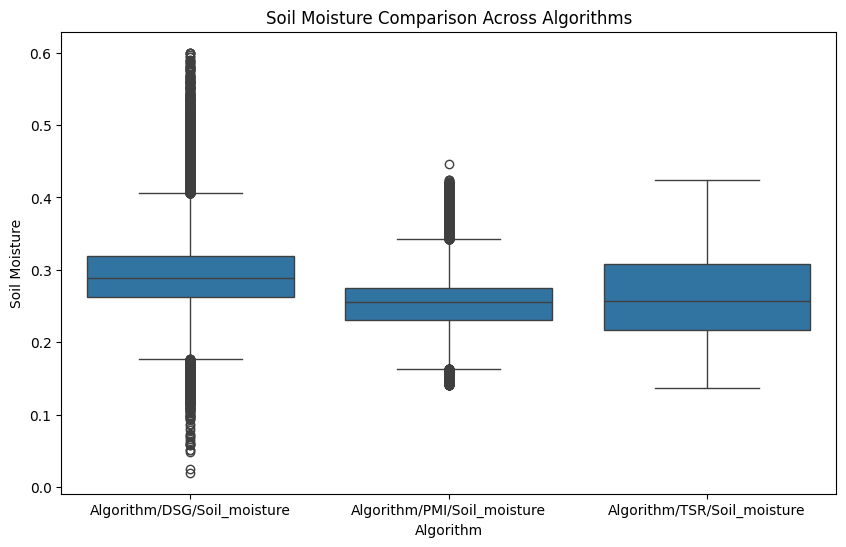

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert soil moisture columns to numeric
df['Algorithm/DSG/Soil_moisture'] = pd.to_numeric(df['Algorithm/DSG/Soil_moisture'], errors='coerce')
df['Algorithm/PMI/Soil_moisture'] = pd.to_numeric(df['Algorithm/PMI/Soil_moisture'], errors='coerce')
df['Algorithm/TSR/Soil_moisture'] = pd.to_numeric(df['Algorithm/TSR/Soil_moisture'], errors='coerce')

# Create a long-format DataFrame for plotting
df_melted = df.melt(value_vars=['Algorithm/DSG/Soil_moisture', 'Algorithm/PMI/Soil_moisture',
                                'Algorithm/TSR/Soil_moisture'],
                    var_name='Algorithm', value_name='Soil Moisture')

# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Algorithm', y='Soil Moisture', data=df_melted)
plt.title('Soil Moisture Comparison Across Algorithms')
plt.show()

### Water Distribution in the area

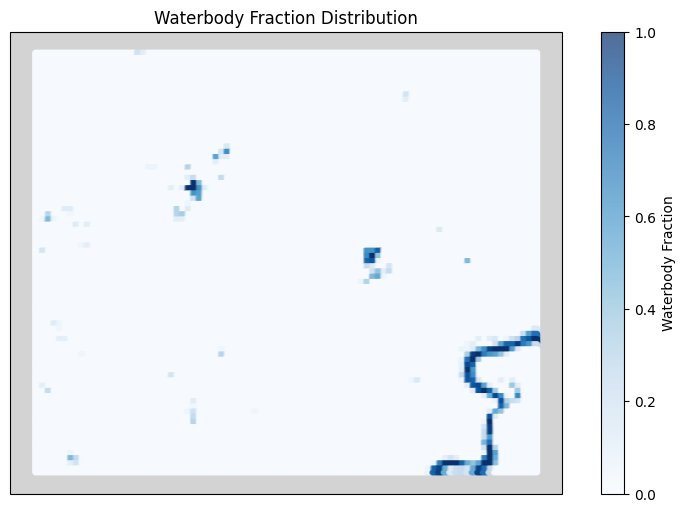

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Scatter plot of waterbody fraction
scatter = ax.scatter(df['longitude'], df['latitude'],
                     c=df['Waterbody_fraction'], cmap='Blues',
                     s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.colorbar(scatter, label='Waterbody Fraction')
plt.title('Waterbody Fraction Distribution')
plt.show()

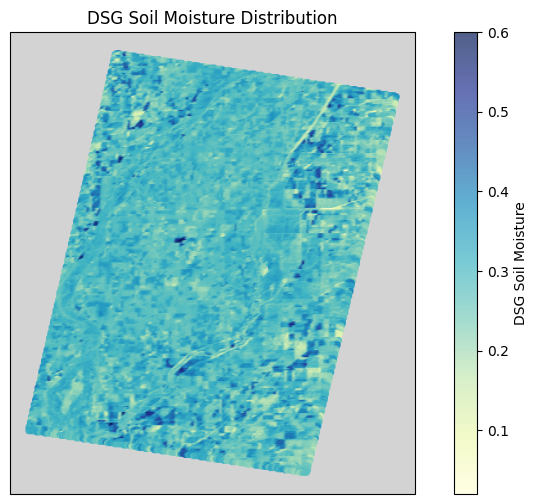

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Convert soil moisture columns to numeric (if object type)
df['Algorithm/DSG/Soil_moisture'] = pd.to_numeric(df['Algorithm/DSG/Soil_moisture'], errors='coerce')
df['Algorithm/PMI/Soil_moisture'] = pd.to_numeric(df['Algorithm/PMI/Soil_moisture'], errors='coerce')
df['Algorithm/TSR/Soil_moisture'] = pd.to_numeric(df['Algorithm/TSR/Soil_moisture'], errors='coerce')

# Filter non-null soil moisture values for DSG
df_dsg = df.dropna(subset=['Algorithm/DSG/Soil_moisture'])

# Create a map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Scatter plot of DSG soil moisture
scatter = ax.scatter(df_dsg['longitude'], df_dsg['latitude'],
                     c=df_dsg['Algorithm/DSG/Soil_moisture'], cmap='YlGnBu',
                     s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.colorbar(scatter, label='DSG Soil Moisture')
plt.title('DSG Soil Moisture Distribution')
plt.show()

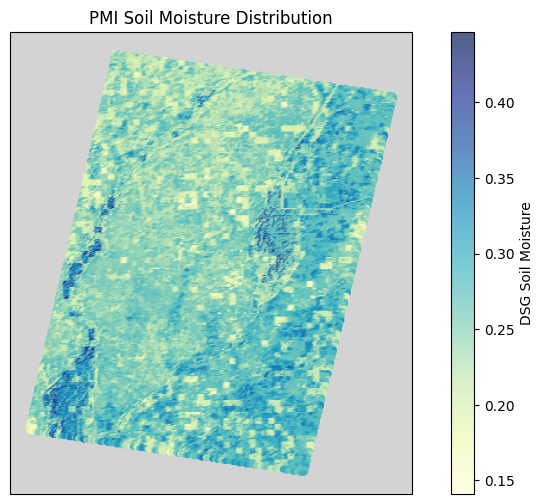

In [ ]:
# Filter non-null soil moisture values for DSG
df_dsg = df.dropna(subset=['Algorithm/PMI/Soil_moisture'])

# Create a map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Scatter plot of DSG soil moisture
scatter = ax.scatter(df_dsg['longitude'], df_dsg['latitude'],
                     c=df_dsg['Algorithm/PMI/Soil_moisture'], cmap='YlGnBu',
                     s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.colorbar(scatter, label='DSG Soil Moisture')
plt.title('PMI Soil Moisture Distribution')
plt.show()

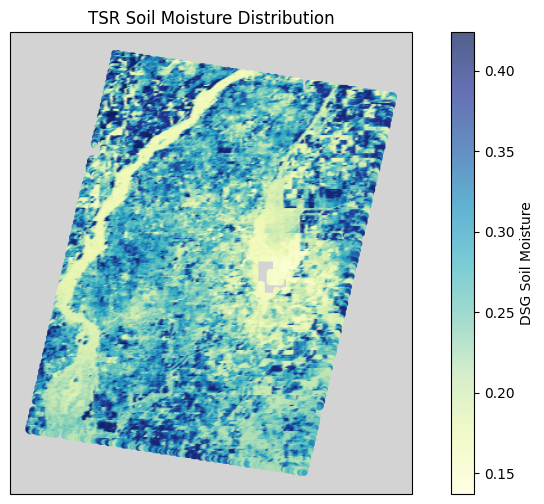

In [ ]:

# Filter non-null soil moisture values for DSG
df_dsg = df.dropna(subset=['Algorithm/TSR/Soil_moisture'])

# Create a map
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.OCEAN, color='lightblue')
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

# Scatter plot of DSG soil moisture
scatter = ax.scatter(df_dsg['longitude'], df_dsg['latitude'],
                     c=df_dsg['Algorithm/TSR/Soil_moisture'], cmap='YlGnBu',
                     s=10, alpha=0.7, transform=ccrs.PlateCarree())

plt.colorbar(scatter, label='DSG Soil Moisture')
plt.title('TSR Soil Moisture Distribution')
plt.show()